# Giai đoạn 2: Huấn luyện Mô hình với dữ liệu MIMIC
Huấn luyện Random Forest, có sử dụng Z-Score Normalization chống Domain Shift.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import os

### 1. Đọc dữ liệu đã trích xuất

In [2]:
df = pd.read_csv('../../data/features/mimic_train_features.csv')
print(f"Tổng số mẫu: {len(df)}")
print(df['status'].value_counts())

X = df.drop(columns=['status'])
y = df['status']

Tổng số mẫu: 1342
status
1    741
0    601
Name: count, dtype: int64


### 2. Tiền xử lý (Train/Test Split & StandardScaler)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


### 3. Huấn luyện mô hình Random Forest

In [4]:
# Khai báo mô hình Pipeline gộp chung Scaler và Random Forest ngay từ đầu
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf_model', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced'))
])

# Huấn luyện toàn bộ chuỗi Pipeline bằng dữ liệu gốc (chưa qua scale)
model_pipeline.fit(X_train, y_train)

# Lưu lại Pipeline duy nhất
os.makedirs('../../models', exist_ok=True)
joblib.dump(model_pipeline, '../../models/mimic_afib_pipeline.pkl')
print("Đã lưu mô hình Pipeline gộp chung tại: models/mimic_afib_pipeline.pkl")


Đã lưu mô hình Pipeline gộp chung tại: models/mimic_afib_pipeline.pkl


### 4. Đánh giá

Accuracy: 0.9517

=== Báo cáo Phân loại ===
                 precision    recall  f1-score   support

Bình Thường (0)       0.97      0.92      0.94       120
       AFib (1)       0.94      0.98      0.96       149

       accuracy                           0.95       269
      macro avg       0.95      0.95      0.95       269
   weighted avg       0.95      0.95      0.95       269



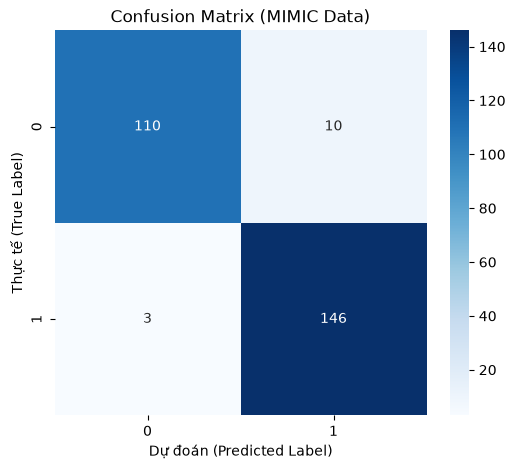


=== Top 5 đặc trưng quan trọng nhất ===
NN50     0.274929
pNN50    0.229988
CV       0.184756
SDNN     0.076348
LF       0.049994
dtype: float64


In [5]:
# Dự đoán thẳng trên dữ liệu gốc (Pipeline sẽ tự động đẩy qua Scaler bên trong)
y_pred = model_pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n=== Báo cáo Phân loại ===")
print(classification_report(y_test, y_pred, target_names=['Bình Thường (0)', 'AFib (1)']))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (MIMIC Data)')
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Dự đoán (Predicted Label)')
plt.show()

# Hiển thị mức độ quan trọng của đặc trưng (Lấy mô hình RF từ bên trong Pipeline)
importances = model_pipeline.named_steps['rf_model'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print("\n=== Top 5 đặc trưng quan trọng nhất ===")
print(feat_imp.head(5))
